In [1]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

## Input univarié

$\left(k_{\theta_0}(x, x')\right)_{o,o'} = \left(\text{Cov}\left(\mu_{0,o}(x), \mu_{0,o'}(x')\right)\right)_{o,o'} \\
= \frac{\sigma_{0,o}^2 \sigma_{0,o'}^2}{\sqrt{2\pi}|l_{0,o}^2 + l_{0,o'}^2 + l_{0,u}^2|^{1/2}} \exp\left(-\frac{1}{2}(x-x')^2(l_{0,o}^2 + l_{0,o'}^2 + l_{0,u}^2)^{-1}\right)$

$\left(k_{\theta_t}(x, x')\right)_{o,o'} = \left(\text{Cov}\left(f_{t,o}(x), f_{t,o'}(x')\right)\right)_{o,o'} \\
= \frac{\sigma_{t,o}^2 \sigma_{t,o'}^2}{\sqrt{2\pi}|l_{t,o}^2 + l_{t,o'}^2 + l_{t,u}^2|^{1/2}} \exp\left(-\frac{1}{2}(x-x')^2(l_{t,o}^2 + l_{t,o'}^2 + l_{t,u}^2)^{-1}\right)$

---

Le noyau des mean process :

Le noyaux des tâches :

Avec :

**sigma_k,o :** variance de l'output o (scalaire)

**l_k,o,i :** lengthscale de l'output o pour l'input i (scalaire)

**l_t,i :** lengthscale du noyau de convolution pour l'input i (scalaire)


**x, x' :** inputs 1 et 2 (scalaires)

**o, o' :** output 1 et 2 (scalaires)

## Naive implem

In [6]:
def mo_kern_univariate(x_1, x_2, var_1, var_2, ls_1, ls_2, ls_u):
	return var_1**2 * var_2**2 / jnp.sqrt(2 * jnp.pi * (ls_1**2 + ls_2**2 + ls_u**2)) * jnp.exp(-0.5 * (x_1 - x_2)**2 / (ls_1**2 + ls_2**2 + ls_u**2))

In [8]:
@jit
def mo_kern_magma_pairwise(x_1, x_2, var_1, var_2, ls_1, ls_2, ls_u, noise):
	"""
	Computes the correlation between two inputs for the multi-output kernel.

	:param x_1: first input point (shape (I, ))
	:param x_2: second input point (shape (I, ))
	:param var_1: variance of the first output (scalar)
	:param var_2: variance of the second output (scalar)
	:param ls_1: lengthscales of each input dimension for the first output (shape (I, ))
	:param ls_2: lengthscales of each input dimension for the second output (shape (I, ))
	:param ls_u: lengthscales of each input dimension for the convolution kernel (shape (I, ))
	:return: kernel value (scalar)
	"""
	# Exponentiate parameters
	var_1 = jnp.exp(var_1)
	var_2 = jnp.exp(var_2)
	ls_1 = jnp.exp(ls_1)
	ls_2 = jnp.exp(ls_2)
	ls_u = jnp.exp(ls_u)
	noise = jnp.exp(noise)

	# As the formula only involves diagonal matrices, we can compute directly with vectors

	sigma_diag = ls_1 + ls_2 + ls_u  # Σ
	sigma_det = jnp.prod(sigma_diag)  # |Σ|
	diff = x_1 - x_2  # x - x'

	# Compute the quadratic form: (x - x')^T Sigma^{-1} (x - x')
	# Since Sigma^{-1} is diagonal, this simplifies to sum of (diff_i^2 * sigma_inv_diag_i)
	quadratic_form = jnp.sum(diff**2 / sigma_diag)

	res = var_1 * var_2 /(((2 * jnp.pi)**(len(x_1)/2)) * jnp.sqrt(sigma_det)) * jnp.exp(-0.5 * quadratic_form)

	# Compute the kernel value
	return cond(jnp.all(x_1 == x_2),
	            lambda : res + noise,
	            lambda : res)

In [10]:
mo_kern_matrix = vmap(vmap(mo_kern, in_axes=(0, None, None, None, None, None, None)), in_axes=(None, 0, None, None, None, None, None))(jnp.linspace(-3, 3, 100)[:, None], jnp.linspace(-3, 3, 100)[:, None], var_o_1, var_o_2, ls_o_1, ls_o_2, ls_u).squeeze()
mo_kern_matrix.shape

(100, 100)

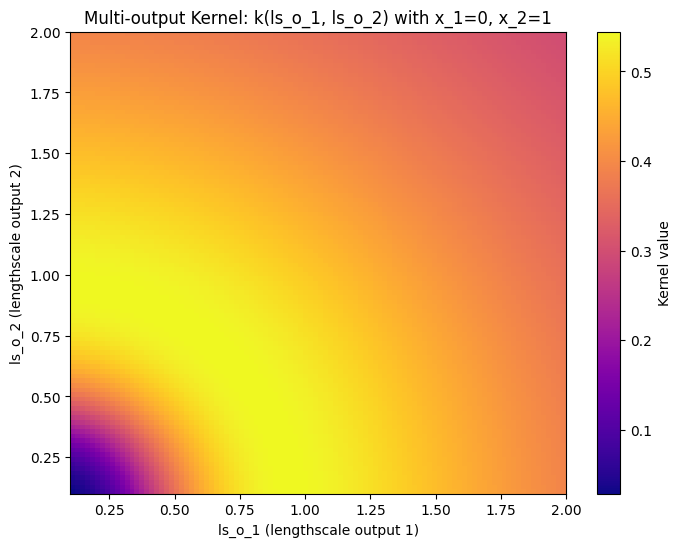

In [12]:
# Create grid of ls_o_1 and ls_o_2 values from 0.1 to 2
ls_o_1_vals = jnp.linspace(0.1, 2, 100)
ls_o_2_vals = jnp.linspace(0.1, 2, 100)

# Fix x_1 and x_2 at 0 and 1 respectively
x_1_fixed = jnp.array([0.])
x_2_fixed = jnp.array([1.])

# Calculate kernel values for each lengthscale combination
kernel_vals_ls = vmap(vmap(mo_kern, in_axes=(None, None, None, None, 0, None, None)), in_axes=(None, None, None, None, None, 0, None))(x_1_fixed, x_2_fixed, var_o_1, var_o_2, ls_o_1_vals, ls_o_2_vals, ls_u)

# Create 2D imshow
plt.figure(figsize=(8, 6))
plt.imshow(kernel_vals_ls, extent=[0.1, 2, 0.1, 2], origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(label='Kernel value')
plt.xlabel('ls_o_1 (lengthscale output 1)')
plt.ylabel('ls_o_2 (lengthscale output 2)')
plt.title('Multi-output Kernel: k(ls_o_1, ls_o_2) with x_1=0, x_2=1')
plt.show()

## R implem comparison

In [14]:
db = pd.read_csv("../../datasets/mo_test.csv")
db.head()

,Task_ID,Input_ID,Input,Output_ID,Output
0,1,1,-0.741682,1,3.450341
1,1,1,-0.663896,1,3.132824
2,1,1,-0.063963,1,0.402541
3,1,1,0.099967,1,5.078131
4,1,1,0.146653,1,7.513049


In [16]:
np.asarray(padded_inputs.squeeze())

array([[-0.74168205, -0.66389616, -0.18943564, -0.11038154, -0.06396297,
         0.09996748,  0.14665267,  0.66689763,  0.70709691,  0.95279698],
       [-0.85004115, -0.74168205, -0.18943564, -0.06396297,  0.09996748,
         0.40474807,  0.66689763,  0.70709691,  0.88694992,  0.95279698],
       [-0.85004115, -0.74168205, -0.11038154, -0.06396297,  0.09996748,
         0.10534813,  0.40474807,  0.66689763,  0.70709691,  0.88694992]])

In [18]:
ls = jnp.array([-6.396930, -5.298317])
vars = jnp.array([0.000000, 1.609438])
lu = jnp.array([-5.298317])
noise = jnp.array([-3., -3.])

In [20]:
mo_kern_magma_crosscov = vmap(vmap(mo_kern_magma_pairwise, in_axes=(0, None, None, None, None, None, None, None)), in_axes=(None, 0, None, None, None, None, None, None))

In [22]:
rows, cols = jnp.triu_indices(padded_outputs.shape[-1])
rows, cols

(Array([0, 0, 1], dtype=int64), Array([0, 1, 1], dtype=int64))

In [24]:
outputs_mask = padded_outputs/padded_outputs
outputs_mask

Array([[[ 1., nan],
        [ 1., nan],
        [nan,  1.],
        [nan,  1.],
        [ 1., nan],
        [ 1., nan],
        [ 1., nan],
        [ 1., nan],
        [nan,  1.],
        [nan,  1.]],

       [[nan,  1.],
        [ 1., nan],
        [nan,  1.],
        [ 1., nan],
        [ 1., nan],
        [ 1., nan],
        [ 1., nan],
        [nan,  1.],
        [ 1., nan],
        [nan,  1.]],

       [[nan,  1.],
        [ 1., nan],
        [nan,  1.],
        [ 1., nan],
        [ 1., nan],
        [nan,  1.],
        [ 1., nan],
        [ 1., nan],
        [nan,  1.],
        [ 1., nan]]], dtype=float64, weak_type=True)

In [26]:
np.asarray(blocks[2])

array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan],
       [           nan,            nan, 8.14835384e+01, 6.61200192e+01,
                   nan,            nan,            nan,            nan,
        1.88381164e-10, 1.05538681e-17],
       [           nan,            nan, 6.61200192e+01, 8.14835384e+01,
                   nan,            nan,            nan,            nan,
        1.72422611e-08, 3.52645977e-15],
       [           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan],
       [           nan,            nan,            nan,            nan,
   

## As a Kernax kernel

In [28]:
from kernax import AbstractKernel, StaticAbstractKernel, BlockKernel, BlockDiagKernel, DiagKernel, ExpKernel

### Test single sub-matrix

In [31]:
np.asarray(full_kernel(padded_inputs[0]))

array([[4.41998061e+00, 3.03972993e+00, 4.93781915e-08, 1.80081717e-10,
        4.70037263e-12, 1.52029832e-18, 1.19506307e-20, 8.70101227e-52,
        8.84073973e-55, 6.64027476e-75],
       [3.03972993e+00, 4.41998061e+00, 5.95095531e-06, 4.53934915e-08,
        1.82738309e-09, 2.73006846e-15, 3.31810178e-17, 3.10496833e-46,
        4.59131749e-49, 3.41714124e-68],
       [4.93781915e-08, 5.95095531e-06, 4.41998061e+00, 3.00366835e+00,
        1.69927883e+00, 2.87119382e-02, 4.97906498e-03, 3.40596272e-19,
        4.96722888e-21, 4.39727872e-34],
       [1.80081717e-10, 4.53934915e-08, 3.00366835e+00, 4.41998061e+00,
        3.84020701e+00, 3.07280205e-01, 8.29773560e-02, 7.89632127e-16,
        1.68623194e-17, 1.53551611e-29],
       [4.70037263e-12, 1.82738309e-09, 1.69927883e+00, 3.84020701e+00,
        4.41998061e+00, 8.71461001e-01, 3.05217904e-01, 5.26756501e-14,
        1.40717870e-15, 5.03574963e-27],
       [1.52029832e-18, 2.73006846e-15, 2.87119382e-02, 3.07280205e-01,
   

In [32]:
mo_bia = deepcopy(mo_kernel)
mo_bia.length_scale_1 = 0
mo_bia.length_scale_2 = 1
mo_bia.length_scale_u = None
mo_bia.variance_1 = 0
mo_bia.variance_2 = 1
mo_bia

MOKernel(
  length_scale_1=0,
  length_scale_2=1,
  length_scale_u=None,
  variance_1=0,
  variance_2=1
)

In [34]:
block_mo_kernel = deepcopy(block_mo_kernel)

In [36]:
block_noise_kernel = deepcopy(block_noise_kernel)
block_noise_kernel.inner_kernel.inner_kernel.inner_kernel.value = noise
print(block_noise_kernel)

BlockDiagDiag(Exp([-3.00 ± 0.00]₂))


In [38]:
full_cov = full_kernel(padded_inputs[0])
full_cov.shape

(20, 20)

In [40]:
%%timeit

full_kernel(padded_inputs[0]).block_until_ready()

52.3 μs ± 495 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
mo_bia = deepcopy(mo_kernel)
mo_bia.length_scale_1 = 0
mo_bia.length_scale_2 = 1
mo_bia.length_scale_u = None
mo_bia.variance_1 = 0
mo_bia.variance_2 = 1
mo_bia

MOKernel(
  length_scale_1=0,
  length_scale_2=1,
  length_scale_u=None,
  variance_1=0,
  variance_2=1
)

In [43]:
block_mo_kernel = deepcopy(block_mo_kernel)

In [45]:
block_noise_kernel = deepcopy(block_noise_kernel)
block_noise_kernel.inner_kernel.inner_kernel.inner_kernel.value = noise
print(block_noise_kernel)

BlockDiagDiag(Exp([-3.00 ± 0.00]₂))


In [48]:
padded_outputs[0]/padded_outputs[0] * padded_inputs[0]

Array([[-0.74168205,         nan],
       [-0.66389616,         nan],
       [        nan, -0.18943564],
       [        nan, -0.11038154],
       [-0.06396297,         nan],
       [ 0.09996748,         nan],
       [ 0.14665267,         nan],
       [ 0.66689763,         nan],
       [        nan,  0.70709691],
       [        nan,  0.95279698]], dtype=float64, weak_type=True)

In [50]:
full_cov = full_kernel((padded_outputs[0]/padded_outputs[0] * padded_inputs[0]).T[:, :, None])
full_cov.shape

(20, 20)

In [52]:
%%timeit

full_kernel((padded_outputs[0]/padded_outputs[0] * padded_inputs[0]).T[:, :, None]).block_until_ready()

385 μs ± 6.35 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
